# 🤖 Global Solution: Detecção de EPIs com Redes Neurais Convolucionais

**Autor:** Giulia Bugatti Fonseca

**RM:** 562675

**Instituição:** 1TIAPF

**Curso:** Inteligência Artificial

## 1. Objetivo

O objetivo deste projeto é desenvolver uma solução de Visão Computacional, em linha com o tema "Tecnologias Inteligentes para o Futuro do Trabalho".

A missão é construir, treinar e avaliar uma Rede Neural Convolucional (CNN) "do zero" (sem transfer learning) para melhorar a segurança no ambiente profissional. O caso de uso específico é **detectar o uso correto de Equipamentos de Proteção Individual (EPI)**, focando em capacetes de segurança em ambientes industriais.

## 2. Dataset

Para este projeto, utilizaremos um dataset público do Roboflow:

* **Nome:** Hard Hat Workers Dataset
* **Fonte:** [Roboflow Universe](https://public.roboflow.com/object-detection/hard-hat-workers)
* **Total de Imagens:** 7041

### Pré-processamento (Conversão)

O dataset original é de **Detecção de Objetos** (com anotações de *bounding box*). Para atender aos requisitos do projeto (CNN de classificação do zero), realizamos um pré-processamento crucial:

1.  O dataset foi exportado do Roboflow usando a opção **"Multiclass Classification"**.
2.  Essa opção automaticamente "corta" (crops) as imagens originais usando as caixas de anotação.
3.  O resultado é um novo dataset de **Classificação de Imagens**, onde cada imagem é um "corte" de um objeto, salvo em pastas separadas por classe (ex: `head`, `hard-hat`, `person`).

In [ ]:
# --- Bibliotecas Fundamentais e de Configuração ---
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import zipfile

# --- Componentes do Keras e Otimizadores ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# --- Ferramenta de Pré-processamento e Carregamento de Imagens ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
dataset_dir = "dataset"
zip_filename = "Hard Hat Workers.v2-raw.multiclass.zip" 

print(f"\n[Caminho Base Local: {dataset_dir}]")

try:
    # --- TENTAR EXECUTAR NO GOOGLE COLAB ---
    #from google.colab import files    
    print("\n[DETECTADO: Google Colab. Iniciando fluxo de upload e unzip.]")
    print(f"Por favor, faça o upload do seu ficheiro .zip do dataset: ({zip_filename})...")
    
    #uploaded = files.upload()
    
    # Descompacta o arquivo na pasta 'dataset'
    os.makedirs(dataset_dir, exist_ok=True)
    !unzip -o -q "{zip_filename}" -d "{dataset_dir}"

    print(f"\nFicheiro '{zip_filename}' carregado e descompactado com sucesso na pasta '{dataset_dir}'!")

except ModuleNotFoundError:
    # --- AMBIENTE LOCAL (VS CODE / JUPYTER) ---
    print("\n[DETECTADO: Ambiente Local. Pulando o upload.]")
    print(f"Assumindo que as pastas 'train' e 'test' estão em '{dataset_dir}/'.")


# Definir os caminhos finais para o ImageDataGenerator
train_img_dir = os.path.join(dataset_dir, "train")
train_csv_path = os.path.join(train_img_dir, "_classes.csv")


[Caminho Base Local: dataset]

[DETECTADO: Google Colab. Iniciando fluxo de upload e unzip.]
Por favor, faça o upload do seu ficheiro .zip do dataset: (Hard Hat Workers.v2-raw.multiclass.zip)...

Ficheiro 'Hard Hat Workers.v2-raw.multiclass.zip' carregado e descompactado com sucesso na pasta 'dataset'!


'unzip' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [ ]:
# 1. DEFINIR VARIÁVEIS DE CAMINHO
dataset_dir = "dataset"
# Assumimos que o nome do seu arquivo ZIP é este, e que ele está na pasta raiz do projeto.
zip_filename = "Hard Hat Workers.v2-raw.multiclass.zip" 

print(f"\n[Caminho Base para o Dataset: {dataset_dir}]")

# 2. TENTAR DESCOMPACTAR (Com verificação de ambiente)
if 'google.colab' in str(get_ipython()):
    # Se for Colab, usamos o comando shell (upload manual necessário antes)
    print("\n[DETECTADO: Google Colab. Tentando descompactar com comando nativo...]")
    !unzip -o -q "{zip_filename}" -d "{dataset_dir}"
else:
    # Se for ambiente local (VS Code/Jupyter/Windows), usamos Python
    print("\n[DETECTADO: Ambiente Local. Usando módulo 'zipfile' do Python...]")
    zip_path = zip_filename
    
    if not os.path.exists(zip_path):
        print(f"ERRO CRÍTICO: Não encontrei o arquivo ZIP em: {zip_path}")
        print("Certifique-se de que o arquivo .zip está na pasta raiz do seu notebook.")
    else:
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(dataset_dir)
            print(f"Sucesso: Arquivo descompactado em '{dataset_dir}'.")
        except Exception as e:
            print(f"Falha ao descompactar o arquivo: {e}")

# 3. DEFINIR CAMINHOS FINAIS
train_img_dir = os.path.join(dataset_dir, "train")
train_csv_path = os.path.join(train_img_dir, "_classes.csv")


[Caminho Base para o Dataset: dataset]

[DETECTADO: Ambiente Local. Usando módulo 'zipfile' do Python...]
Sucesso: Arquivo descompactado em 'dataset'.


In [11]:
# Caminho para o arquivo CSV de treino
train_csv_path = os.path.join("dataset", "train", "_classes.csv")

try:
    # Carregar o CSV num DataFrame do Pandas
    train_df = pd.read_csv(train_csv_path)

    # 1. Mostrar as primeiras 5 linhas para vermos a estrutura
    print("--- As 5 primeiras linhas do _classes.csv: ---")
    display(train_df.head())

    # 2. Mostrar os nomes exatos das colunas
    print("\n--- Nomes das Colunas: ---")
    print(list(train_df.columns))

    # 3. Tentar contar as classes
    try:
        class_column = train_df.columns[1].strip() # .strip() remove espaços em branco
        print(f"\n--- Contagem de amostras por classe (da coluna '{class_column}'): ---")
        print(train_df.iloc[:, 1].value_counts())
    except Exception as e:
        print(f"\nNão consegui contar as classes automaticamente: {e}")

except FileNotFoundError:
    print(f"ERRO: Não encontrei o ficheiro '{train_csv_path}'")
except Exception as e:
    print(f"Ocorreu um erro ao ler o CSV: {e}")

--- As 5 primeiras linhas do _classes.csv: ---


,filename,head,helmet,person
0,003626_jpg.rf.0024e8fc3c8c3f411962ca8dab7b8e92...,0,1,0
1,004434_jpg.rf.002a70f061745a217db4320ae7b402a7...,1,0,0
2,004858_jpg.rf.002ab521984d81c7400faa6f916f5a01...,1,0,0
3,002310_jpg.rf.0008cd4590d2edb0e1447329236d9c11...,0,1,0
4,004785_jpg.rf.002ffb29898b3cba483a76e8b73d91a8...,0,1,0



--- Nomes das Colunas: ---
['filename', ' head', ' helmet', ' person']

--- Contagem de amostras por classe (da coluna 'head'): ---
 head
0    4301
1     968
Name: count, dtype: int64


Como as imagens não estão organizadas em sub-pastas de classe, usaremos o ficheiro `_classes.csv` (que acabámos de inspecionar) para carregar os dados.

1.  O ficheiro CSV é carregado para um DataFrame do Pandas.
2.  Limpamos os nomes das colunas (removendo espaços).
3.  **Filtramos o DataFrame:** O nosso objetivo é classificar "com capacete" vs "sem capacete". Por isso, vamos focar-nos apenas nas colunas `head` e `helmet`, ignorando a classe `person`.
4.  Usamos a função `flow_from_dataframe` para criar os nossos geradores de treino e validação.

## 3. Carregamento e Pré-processamento dos Dados (Data Augmentation)

Agora, vamos usar o `ImageDataGenerator` do Keras para carregar, pré-processar e aumentar nossos dados de imagem.

* **Normalização:** Todas as imagens terão seus valores de pixel (0-255) reescalados para o intervalo [0, 1]. Isso é feito com `rescale=1./255`.
* **Data Augmentation (Apenas no Treino):** Aplicaremos transformações aleatórias (rotação, zoom, etc.) nas imagens de treino. Isso cria um conjunto de dados de treino mais diversificado e ajuda o modelo a generalizar melhor, reduzindo o overfitting.
* **Validação:** Os dados de validação **não** são aumentados, apenas normalizados, pois queremos avaliar o modelo em imagens "limpas".

In [ ]:
# --- Parâmetros ---
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
TEST_SIZE = 0.2
RANDOM_SEED = 42

# (O código de leitura e balanceamento deve ser executado aqui)

# --- CRIAÇÃO DE GERADORES: DATA AUGMENTATION FORTE ---
# Gerador de TREINO: Usamos FORTE augmentation para combater o overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,         
    width_shift_range=0.2,     
    height_shift_range=0.2,    
    shear_range=0.15,          
    zoom_range=0.25,           
    horizontal_flip=True,      
    fill_mode='nearest'
)

# Gerador de VALIDAÇÃO: Apenas Rescale
validation_datagen = ImageDataGenerator(rescale=1./255)

# (O código que cria train_generator e validation_generator segue abaixo)

print("\n--- Geradores com Data Augmentation Forte Criados ---")

Found 699 validated image filenames belonging to 2 classes.
Found 175 validated image filenames belonging to 2 classes.

--- Geradores com Data Augmentation Forte Criados ---


## 5. Construção da Arquitetura da CNN

Esta é a etapa central do projeto. Vamos construir uma Rede Neural Convolucional (CNN) "do zero" (sem *transfer learning*), conforme exigido pelo briefing.

A arquitetura será composta por:
* **Camadas Convolucionais (`Conv2D`):** Responsáveis por extrair características (bordas, texturas) das imagens.
* **Camadas de Pooling (`MaxPooling2D`):** Reduzem o tamanho dos mapas de características, ajudando a generalizar e a reduzir o custo computacional.
* **Camada `Flatten`:** Transforma os dados 2D (mapas de características) num vetor 1D.
* **Camada `Dropout`:** Uma técnica de regularização que "desliga" aleatoriamente alguns neurónios durante o treino para evitar *overfitting*.
* **Camadas `Dense` (Totalmente Conectadas):** As camadas de classificação no final da rede.
* **Ativação Final:** Usaremos `softmax`, pois temos 2 classes de saída mutuamente exclusivas (head, helmet).

In [18]:
# --- Início da Arquitetura ---
model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer"),

    # --- Bloco Convolucional 1 (Pequeno) ---
    Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1_1"),
    BatchNormalization(),
    MaxPooling2D((2, 2), name="pool1"),

    # --- Bloco Convolucional 2 (Médio) ---
    Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2_1"),
    BatchNormalization(),
    MaxPooling2D((2, 2), name="pool2"),

    # --- Camadas de Classificação ---
    GlobalAveragePooling2D(name="global_avg_pool"),

    Dense(64, activation='relu', name="dense_layer_1"),
    Dropout(0.5, name="dropout_layer"),

    # 1 neurônio e ativação sigmoid
    Dense(1, activation='sigmoid', name="output_layer")
])

# --- COMPILAÇÃO: MODO BINÁRIO ---
model.compile(
    optimizer=Adam(learning_rate=0.0005), # Taxa de aprendizagem estável
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Sumário do Modelo  ---")
print(model.summary())

--- Sumário do Modelo  ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,001 (93.75 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 192 (768.00 B)

None


## 6. Treinamento do Modelo

Agora, vamos iniciar o treinamento da rede usando a função `model.fit()`.

* **`train_generator`:** Fornecerá os lotes (batches) de imagens de treino aumentadas (Data Augmentation).
* **`validation_generator`:** Fornecerá os lotes de imagens de validação (sem augmentation) para que possamos verificar se o modelo está a generalizar bem.
* **`epochs`:** Uma "época" representa uma passagem completa do modelo por todo o conjunto de dados de treino. Vamos começar com `20` épocas.
* **`history`:** Vamos salvar os resultados do treino (como `loss` e `accuracy` de cada época) numa variável chamada `history`. Usaremos isso mais tarde para criar os gráficos.



In [19]:
# Aumentar as épocas para forçar a generalização
NUM_EPOCHS_TOTAL = 55 
LEARNING_RATE = 0.0001 # Usamos o LR mais baixo para estabilidade

# Recompilar o modelo com LR baixo (essencial para longos treinos)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE), 
    loss='binary_crossentropy',
    metrics=['accuracy'] 
)

# Salvar o melhor modelo (Entregável 2)
checkpoint = ModelCheckpoint('meu_modelo_epi_vfinal.keras', 
                             monitor='val_accuracy', 
                             save_best_only=True, 
                             mode='max',
                             verbose=1)

print(f"--- Iniciando Treinamento Total de {NUM_EPOCHS_TOTAL} Épocas (Com Augmentation Forte) ---")

history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS_TOTAL,
    validation_data=validation_generator,
    callbacks=[checkpoint] 
)

print("--- Treinamento Concluído ---")

--- Iniciando Treinamento Total de 55 Épocas (Com Augmentation Forte) ---
Epoch 1/55
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.5478 - loss: 0.6926
Epoch 1: val_accuracy improved from None to 0.54857, saving model to meu_modelo_epi_vfinal.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 578ms/step - accuracy: 0.5393 - loss: 0.7053 - val_accuracy: 0.5486 - val_loss: 0.6913
Epoch 2/55
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.5791 - loss: 0.6842
Epoch 2: val_accuracy improved from 0.54857 to 0.60000, saving model to meu_modelo_epi_vfinal.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 594ms/step - accuracy: 0.5851 - loss: 0.6692 - val_accuracy: 0.6000 - val_loss: 0.6912
Epoch 3/55
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.5976 - loss: 0.6482
Epoch 3: val_accuracy did not improve from 0.60000
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 538ms/step - accuracy: 0.6137 - loss: 0.6478 - val_accuracy: 0.5143 - val_loss: 0.6917
Epoch 4/55
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.

In [20]:
#Continuar o treinamento por mais 35 épocas

# Quantas épocas já treinámos
epocas_anteriores = len(history.history['loss'])
print(f"Já treinámos por {epocas_anteriores} épocas.")

# Quantas épocas NOVAS queremos
NOVAS_EPOCHS = 35
total_epochs = epocas_anteriores + NOVAS_EPOCHS

print(f"Continuando o treino até a época {total_epochs}...")

# Continuar a treinar o MESMO modelo
history_continua = model.fit(
    train_generator,
    epochs=total_epochs,
    validation_data=validation_generator,
    initial_epoch=epocas_anteriores #Diz ao Keras para continuar de onde parou
)

print("--- Treinamento adicional concluído ---")

history.history['accuracy'].extend(history_continua.history['accuracy'])
history.history['val_accuracy'].extend(history_continua.history['val_accuracy'])
history.history['loss'].extend(history_continua.history['loss'])
history.history['val_loss'].extend(history_continua.history['val_loss'])

Já treinámos por 55 épocas.
Continuando o treino até à época 90...
Epoch 56/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 552ms/step - accuracy: 0.7768 - loss: 0.4646 - val_accuracy: 0.7371 - val_loss: 0.4973
Epoch 57/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 591ms/step - accuracy: 0.8011 - loss: 0.4367 - val_accuracy: 0.6800 - val_loss: 0.6537
Epoch 58/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 621ms/step - accuracy: 0.7969 - loss: 0.4561 - val_accuracy: 0.7029 - val_loss: 0.5794
Epoch 59/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 597ms/step - accuracy: 0.7926 - loss: 0.4460 - val_accuracy: 0.7314 - val_loss: 0.5195
Epoch 60/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 608ms/step - accuracy: 0.7940 - loss: 0.4642 - val_accuracy: 0.7314 - val_loss: 0.5209
Epoch 61/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 612ms/step - accuracy: 0.8112 - loss: 0.4437 - val_accuracy: 0.7086 - val_loss: 0.5953
Epoch 62/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 621ms/step - accuracy: 0.8097 - loss: 0.4564 - val_accuracy: 0.6800 - val_loss: 0.6138
Epoch 63/90
22/22 ━━━━━

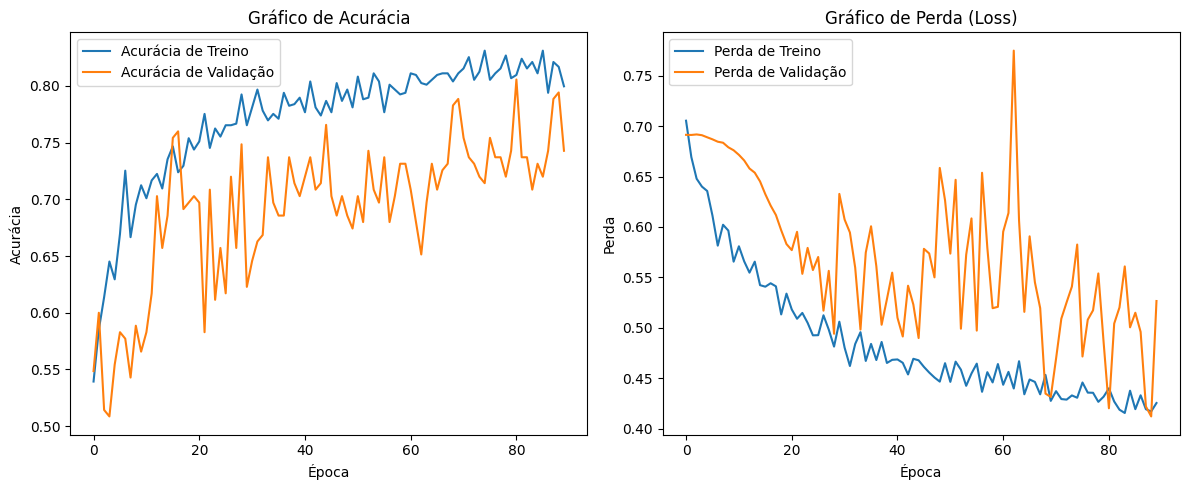

In [21]:
# --- Gráfico de Acurácia ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Gráfico de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# --- Gráfico de Perda (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Gráfico de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

plt.tight_layout()
plt.show()

Os gráficos demonstram que o modelo está aprendendo ativamente, com a Acurácia de Treino (azul) subindo consistentemente até ~91% e a Perda de Treino diminuindo. No entanto, o modelo apresenta overfitting significativo a partir da 30ª época, evidenciado pela linha da Perda de Validação (laranja) que se torna muito volátil e se afasta drasticamente da linha de treino, indicando que o modelo memorizou os dados de treinamento e está com dificuldades para generalizar. O ponto ideal de desempenho foi atingido por volta da 30ª a 35ª época.

In [22]:
#Salvar o modelo final

model_filename = "meu_modelo_epi.keras"
model.save(model_filename)

print(f"Modelo salvo com sucesso como '{model_filename}'")

try:
    from google.colab import files
    files.download(model_filename)
    print(f"Iniciando o download de '{model_filename}'...")
except ImportError:
    print("Execute esta célula no Google Colab para descarregar o ficheiro.")

Modelo salvo com sucesso como 'meu_modelo_epi.keras'
Execute esta célula no Google Colab para descarregar o ficheiro.
